In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# import deepxde as dde
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from mpl_toolkits.mplot3d import Axes3D

In [3]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')

print(list(datastore.keys()))

predictions_c_enhanced_pca = np.array(np.array(datastore["predictions_c_enhanced_pca"]))
predictions_c_enhanced_pca_experimental = np.array(np.array(datastore["predictions_c_enhanced_pca_experimental"]))
predictions_c_enhanced_pca_glob = np.array(np.array(datastore["predictions_c_enhanced_pca_glob"]))

predictions_c_ffn = np.array(np.array(datastore["predictions_c_ffn"]))
predictions_c_ffn_experimental = np.array(np.array(datastore["predictions_c_ffn_calculated"]))
predictions_c_ffn_glob = np.array(np.array(datastore["predictions_c_ffn_glob"]))

predictions_c_pca = np.array(np.array(datastore["predictions_c_pca"]))
predictions_c_pca_experimental = np.array(np.array(datastore["predictions_c_pca_experimental"]))
predictions_c_pca_glob = np.array(np.array(datastore["predictions_c_glob_pca"]))

predictions_h_enhanced_pca = np.array(np.array(datastore["predictions_h_enhanced_pca"]))
predictions_h_enhanced_pca_experimental = np.array(np.array(datastore["predictions_h_enhanced_pca_experimental"]))
predictions_h_enhanced_pca_glob = np.array(np.array(datastore["predictions_h_enhanced_pca_glob"]))

predictions_h_ffn = np.array(np.array(datastore["predictions_h_ffn"]))
predictions_h_ffn_experimental = np.array(np.array(datastore["predictions_h_ffn_calculated"]))
predictions_h_ffn_glob = np.array(np.array(datastore["predictions_h_ffn_glob"]))

predictions_h_pca = np.array(np.array(datastore["predictions_h_pca"]))
predictions_h_pca_experimental = np.array(np.array(datastore["predictions_h_pca_experimental"]))
predictions_h_pca_glob = np.array(np.array(datastore["predictions_h_glob_pca"]))

c_large = np.array(np.array(datastore["c_large"]))
h_large = np.array(np.array(datastore["h_large"]))
f_large = np.array(np.array(datastore["f_large"]))

data_p = np.array(np.array(datastore["parameters_large: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))

t = np.linspace(0, 1, 601).reshape(601, 1)
data_f0 = data_p[:, 4] * 1e3
data_ts = data_p[:, 8]
data_h0 = data_p[:, 7] * 1e6

['I_clean', 'I_large', 'c', 'c_large', 'f', 'f_large', 'h', 'h_large', 'parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts', 'parameters_large: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts', 'predictions_I_enhanced_pca_experimental', 'predictions_c_enhanced_pca', 'predictions_c_enhanced_pca_experimental', 'predictions_c_enhanced_pca_glob', 'predictions_c_ffn', 'predictions_c_ffn_calculated', 'predictions_c_ffn_glob', 'predictions_c_glob_pca', 'predictions_c_pca', 'predictions_c_pca_experimental', 'predictions_h_enhanced_pca', 'predictions_h_enhanced_pca_experimental', 'predictions_h_enhanced_pca_glob', 'predictions_h_ffn', 'predictions_h_ffn_calculated', 'predictions_h_ffn_glob', 'predictions_h_glob_pca', 'predictions_h_pca', 'predictions_h_pca_experimental']


In [4]:
train_label_2, test_label_2 = train_test_split(range(len(c_large)), test_size=0.5, random_state=42)


data_c_2_train = c_large[train_label_2]
data_c_2_test = c_large[test_label_2]

data_h_2_train = h_large[train_label_2]
data_h_2_test = h_large[test_label_2]

data_f_2_train = f_large[train_label_2]
data_f_2_test = f_large[test_label_2]

data_f0_train = data_f0[train_label_2]
data_f0_test = data_f0[test_label_2]

data_ts_train = data_ts[train_label_2]
data_ts_test = data_ts[test_label_2]

data_h0_train = data_h0[train_label_2]
data_h0_test = data_h0[test_label_2]

In [5]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)

data_d_sigma_0_glob = data_p_glob[:,3].reshape(-1, 1)
data_ri_glob = data_p_glob[:,4].reshape(-1, 1)
data_J_e_glob = data_p_glob[:,5].reshape(-1, 1)

datastore_glob.close()

In [6]:
datastore_experimental = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5", 'r')
data_I_calculated = np.array(datastore_experimental["calculated_I"])
data_h_calculated = np.array(datastore_experimental["calculated_h"])
data_f_calculated = np.array(datastore_experimental["calculated_f"])

data_c_caluculated = np.array(datastore_experimental["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore_experimental["nondimensional_p"])

J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f0_data_exp = data_p_experimental_nondimensional[:, 4] * 1e3
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_data_exp = data_p_experimental_nondimensional[:, 7] * 1e6
ts_data_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore_experimental.close()  # Close the read-only handle

Average Relative RMSE for model_c on global data(noisy model with 3 noise levels): 0.21536453568172798
Average Relative RMSE for model_h on global data(noisy model with 3 noise levels): 0.2639528020630202


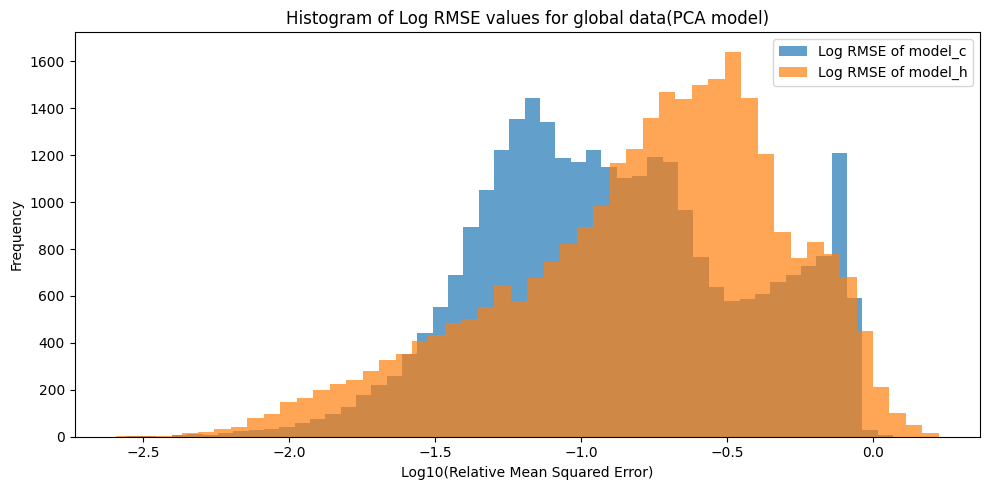

In [7]:
# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_glob_pca = np.sqrt(np.sum((predictions_c_pca_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_glob_pca = np.sqrt(np.sum((predictions_h_pca_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

print(f"Average Relative RMSE for model_c on global data(noisy model with 3 noise levels): {np.mean(rrmse_c_glob_pca)}")
print(f"Average Relative RMSE for model_h on global data(noisy model with 3 noise levels): {np.mean(rrmse_h_glob_pca)}")

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_pca), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_pca), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(PCA model)')
plt.legend()
plt.tight_layout()
plt.show()

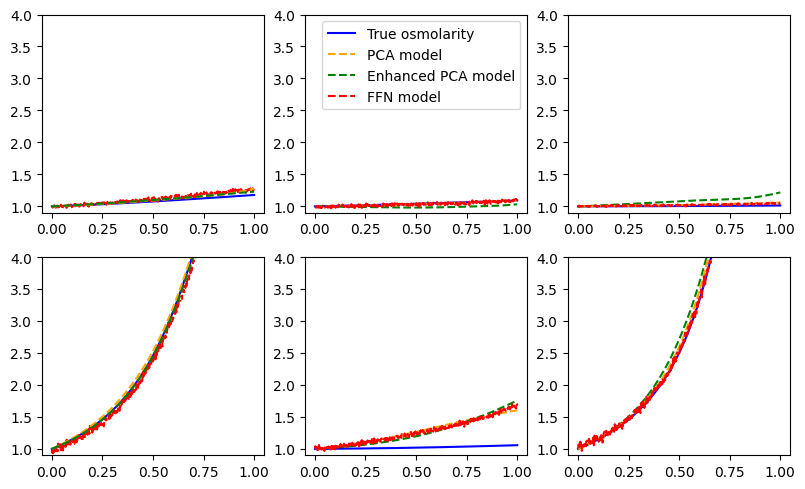

In [8]:
n1, n2, n3, n4, n5, n6 = np.random.randint(len(data_c_2_test), size=6)

fig, ax = plt.subplots(2, 3, figsize=(8, 5))

ax[0, 0].plot(t, data_c_2_test[n1], label='True osmolarity', color='blue')
ax[0, 0].plot(t, predictions_c_ffn[n1], label='FFN model', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_c_enhanced_pca[n1], label='PCA model', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_c_pca[n1], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 0].set_ylim(0.9, 4)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_c_2_test[n2], label='True osmolarity', color='blue')
ax[0, 1].plot(t, predictions_c_pca[n2], label='PCA model', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_c_enhanced_pca[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_c_ffn[n2], label='FFN model', linestyle='--', color='red')
ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].legend()

ax[0, 2].plot(t, data_c_2_test[n3], label='True osmolarity', color='blue')
ax[0, 2].plot(t, predictions_c_enhanced_pca[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_c_pca[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_c_ffn[n3], label='FFN model', linestyle='--', color='red')
ax[0, 2].set_ylim(0.9, 4)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_c_2_test[n4], label='True osmolarity', color='blue')
ax[1, 0].plot(t, predictions_c_ffn[n4], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_c_enhanced_pca[n4], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_c_pca[n4], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 0].set_ylim(0.9, 4)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_c_2_test[n5], label='True osmolarity', color='blue')
ax[1, 1].plot(t, predictions_c_pca[n5], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_c_enhanced_pca[n5], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_c_ffn[n5], label='FFN model', linestyle='--', color='red')
ax[1, 1].set_ylim(0.9, 4)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_c_2_test[n6], label='True osmolarity', color='blue')
ax[1, 2].plot(t, predictions_c_enhanced_pca[n6], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_c_pca[n6], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_c_ffn[n6], label='FFN model', linestyle='--', color='red')
ax[1, 2].set_ylim(0.9, 4)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/6_samples_comparison_c.png", dpi=300)
plt.show()

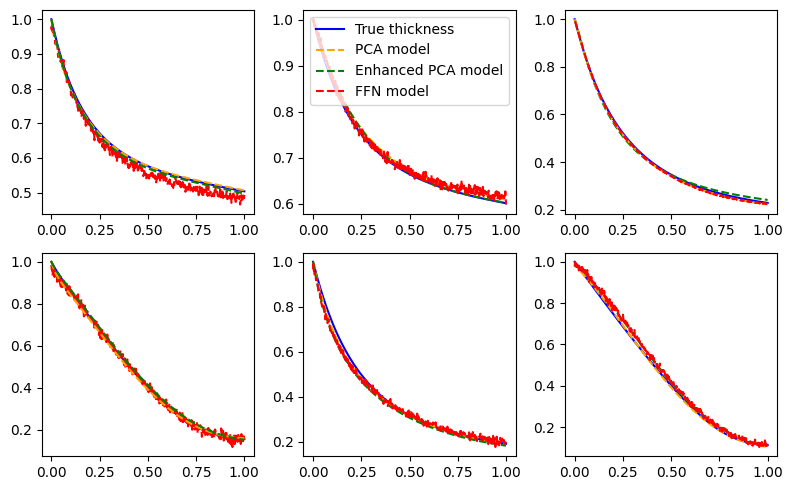

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(8, 5))

ax[0, 0].plot(t, data_h_2_test[n1], label='True thickness', color='blue')
ax[0, 0].plot(t, predictions_h_ffn[n1], label='FFN model', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_h_enhanced_pca[n1], label='PCA model', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_h_pca[n1], label='Enhanced PCA model', linestyle='--', color='green')
# ax[0, 0].set_ylim(0.9, 4)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_h_2_test[n2], label='True thickness', color='blue')
ax[0, 1].plot(t, predictions_h_pca[n2], label='PCA model', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_h_enhanced_pca[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_h_ffn[n2], label='FFN model', linestyle='--', color='red')
# ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].legend()

ax[0, 2].plot(t, data_h_2_test[n3], label='True thickness', color='blue')
ax[0, 2].plot(t, predictions_h_enhanced_pca[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_h_pca[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_h_ffn[n3], label='FFN model', linestyle='--', color='red')
# ax[0, 2].set_ylim(0.9, 4)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_h_2_test[n4], label='True thickness', color='blue')
ax[1, 0].plot(t, predictions_h_ffn[n4], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_h_enhanced_pca[n4], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_h_pca[n4], label='Enhanced PCA model', linestyle='--', color='green')
# ax[1, 0].set_ylim(0.9, 4)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_h_2_test[n5], label='True thickness', color='blue')
ax[1, 1].plot(t, predictions_h_pca[n5], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_h_enhanced_pca[n5], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_h_ffn[n5], label='FFN model', linestyle='--', color='red')
# ax[1, 1].set_ylim(0.9, 4)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_h_2_test[n6], label='True thickness', color='blue')
ax[1, 2].plot(t, predictions_h_enhanced_pca[n6], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_h_pca[n6], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_h_ffn[n6], label='FFN model', linestyle='--', color='red')
# ax[1, 2].set_ylim(0.9, 4)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/6_samples_comparison_h.png", dpi=300)
plt.show()


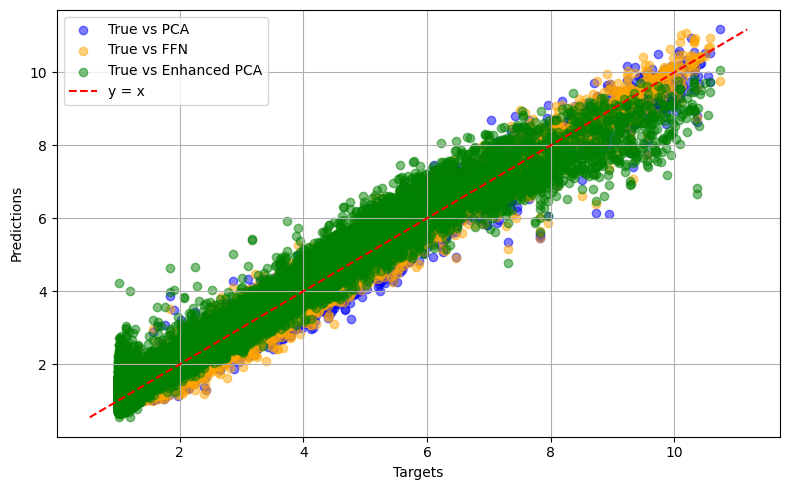

In [10]:
final_c_true = data_c_2_test[:32261,-1].reshape(-1,1)
final_c_pca = predictions_c_pca[:32261,-1].reshape(-1,1)
final_c_enhanced_pca = predictions_c_enhanced_pca[:32261,-1].reshape(-1,1)
final_c_ffn = predictions_c_ffn[:32261,-1].reshape(-1,1)

plt.figure(figsize=(8, 5))
plt.scatter(final_c_true, final_c_pca, label='True vs PCA', color='blue', alpha=0.5)
plt.scatter(final_c_true, final_c_ffn, label='True vs FFN', color='orange', alpha=0.5)
plt.scatter(final_c_true, final_c_enhanced_pca, label='True vs Enhanced PCA', color='green', alpha=0.5)
min_val = min(final_c_true.min(), final_c_pca.min(), final_c_enhanced_pca.min(), final_c_ffn.min())
max_val = max(final_c_true.max(), final_c_pca.max(), final_c_enhanced_pca.max(), final_c_ffn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')
plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Concentration: True vs Predicted (PCA Model)')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_concentration_comparison.png", dpi=300)
plt.show()

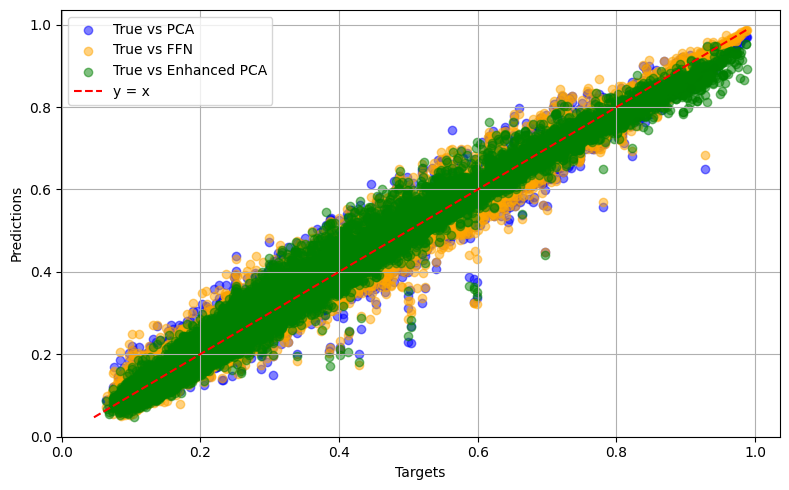

In [11]:
final_h_true = data_h_2_test[:32261,-1].reshape(-1,1)
final_h_pca = predictions_h_pca[:32261,-1].reshape(-1,1)
final_h_enhanced_pca = predictions_h_enhanced_pca[:32261,-1].reshape(-1,1)
final_h_ffn = predictions_h_ffn[:32261,-1].reshape(-1,1)

plt.figure(figsize=(8, 5))
plt.scatter(final_h_true, final_h_pca, label='True vs PCA', color='blue', alpha=0.5)
plt.scatter(final_h_true, final_h_ffn, label='True vs FFN', color='orange', alpha=0.5)
plt.scatter(final_h_true, final_h_enhanced_pca, label='True vs Enhanced PCA', color='green', alpha=0.5)
min_val = min(final_h_true.min(), final_h_pca.min(), final_h_enhanced_pca.min(), final_h_ffn.min())
max_val = max(final_h_true.max(), final_h_pca.max(), final_h_enhanced_pca.max(), final_h_ffn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.legend()
plt.xlabel('Targets')
plt.ylabel('Predictions')
# plt.title('Final Thickness: True vs Predicted (PCA Model)')
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/final_thickness_comparison.png", dpi=300)
plt.show()

In [12]:
rrmse_c_pca = np.sqrt(np.sum((predictions_c_pca - data_c_2_test) ** 2, axis=1) / np.sum(data_c_2_test ** 2, axis=1))
rrmse_c_enhanced_pca = np.sqrt(np.sum((predictions_c_enhanced_pca - data_c_2_test) ** 2, axis=1) / np.sum(data_c_2_test ** 2, axis=1))
rrmse_c_ffn = np.sqrt(np.sum((predictions_c_ffn - data_c_2_test) ** 2, axis=1) / np.sum(data_c_2_test ** 2, axis=1))

rrmse_h_pca = np.sqrt(np.sum((predictions_h_pca - data_h_2_test) ** 2, axis=1) / np.sum(data_h_2_test ** 2, axis=1))
rrmse_h_enhanced_pca = np.sqrt(np.sum((predictions_h_enhanced_pca - data_h_2_test) ** 2, axis=1) / np.sum(data_h_2_test ** 2, axis=1))
rrmse_h_ffn = np.sqrt(np.sum((predictions_h_ffn - data_h_2_test) ** 2, axis=1) / np.sum(data_h_2_test ** 2, axis=1))

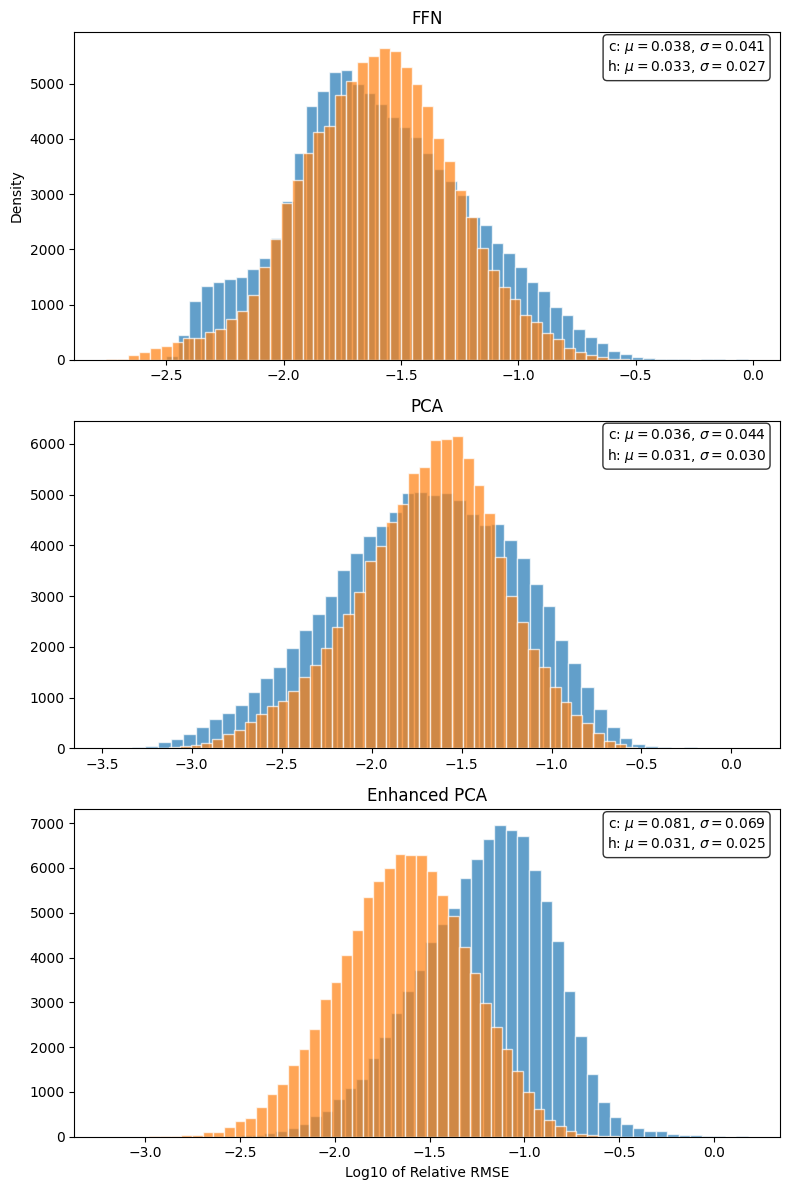

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(8, 12))

# FFN
mean_c_ffn = np.mean(rrmse_c_ffn)
std_c_ffn = np.std(rrmse_c_ffn)
mean_h_ffn = np.mean(rrmse_h_ffn)
std_h_ffn = np.std(rrmse_h_ffn)
ax[0].hist(np.log10(rrmse_c_ffn), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[0].hist(np.log10(rrmse_h_ffn), bins=50, alpha=0.7, label='h', edgecolor='white')
ax[0].set_ylabel('Density')
ax[0].set_title('FFN')
textstr_ffn = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_ffn, std_c_ffn),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_ffn, std_h_ffn)))
ax[0].text(0.98, 0.98, textstr_ffn, transform=ax[0].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# PCA
mean_c_pca = np.mean(rrmse_c_pca)
std_c_pca = np.std(rrmse_c_pca)
mean_h_pca = np.mean(rrmse_h_pca)
std_h_pca = np.std(rrmse_h_pca)
ax[1].hist(np.log10(rrmse_c_pca), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[1].hist(np.log10(rrmse_h_pca), bins=50, alpha=0.7, label='h', edgecolor='white')
# ax[1].legend()
ax[1].set_title('PCA')
textstr_pca = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_pca, std_c_pca),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_pca, std_h_pca)))
ax[1].text(0.98, 0.98, textstr_pca, transform=ax[1].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Enhanced PCA
mean_c_enh = np.mean(rrmse_c_enhanced_pca)
std_c_enh = np.std(rrmse_c_enhanced_pca)
mean_h_enh = np.mean(rrmse_h_enhanced_pca)
std_h_enh = np.std(rrmse_h_enhanced_pca)
ax[2].hist(np.log10(rrmse_c_enhanced_pca), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[2].hist(np.log10(rrmse_h_enhanced_pca), bins=50, alpha=0.7, label='h', edgecolor='white')
ax[2].set_xlabel('Log10 of Relative RMSE')
ax[2].set_title('Enhanced PCA')
textstr_enh = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_enh, std_c_enh),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_enh, std_h_enh)))
ax[2].text(0.98, 0.98, textstr_enh, transform=ax[2].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/rrmse_histograms.png", dpi=300)
plt.show()

In [14]:
rrmse_c_enhanced_pca_glob = np.sqrt(np.sum((predictions_c_enhanced_pca_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_enhanced_pca_glob = np.sqrt(np.sum((predictions_h_enhanced_pca_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

rrmse_c_ffn_glob = np.sqrt(np.sum((predictions_c_ffn_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_ffn_glob = np.sqrt(np.sum((predictions_h_ffn_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

rrmse_c_pca_glob = np.sqrt(np.sum((predictions_c_pca_glob - data_c_glob) ** 2, axis=1) / np.sum(data_c_glob ** 2, axis=1))
rrmse_h_pca_glob = np.sqrt(np.sum((predictions_h_pca_glob - data_h_glob) ** 2, axis=1) / np.sum(data_h_glob ** 2, axis=1))

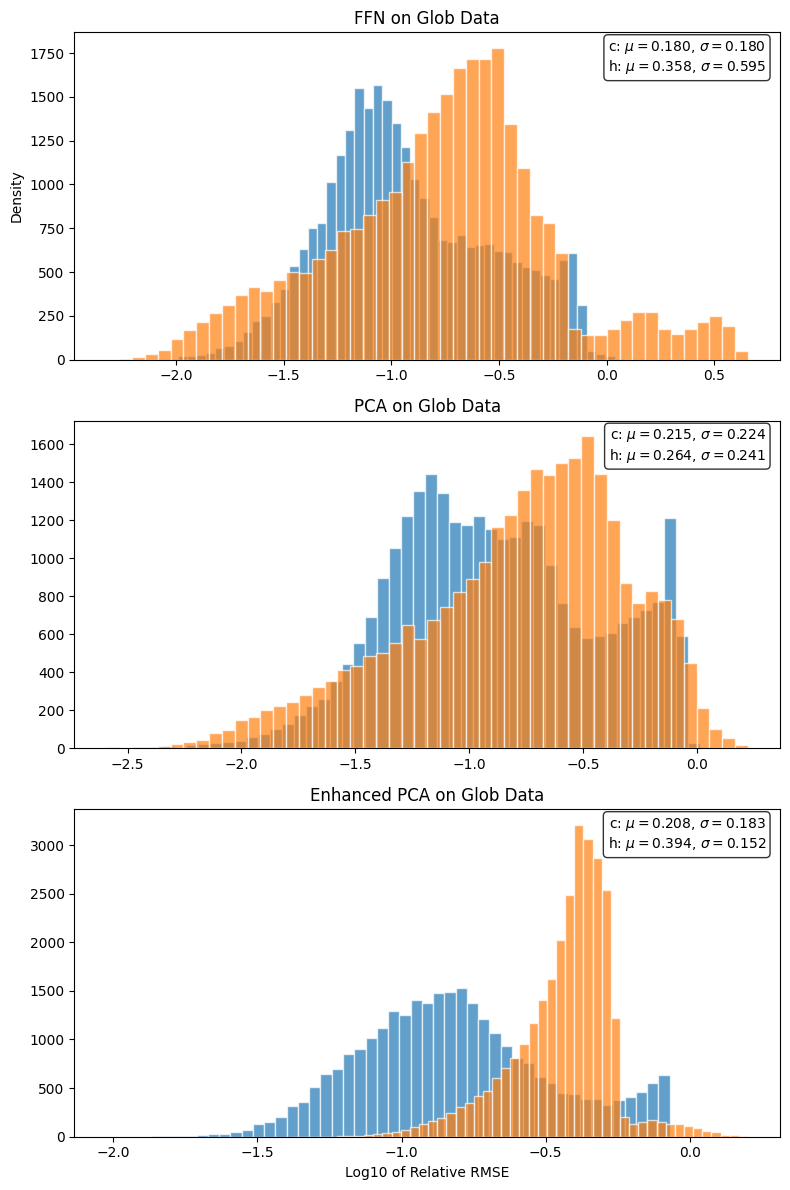

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(8, 12))

# FFN
mean_c_ffn_glob = np.mean(rrmse_c_ffn_glob)
std_c_ffn_glob = np.std(rrmse_c_ffn_glob)
mean_h_ffn_glob = np.mean(rrmse_h_ffn_glob)
std_h_ffn_glob = np.std(rrmse_h_ffn_glob)

ax[0].hist(np.log10(rrmse_c_ffn_glob), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[0].hist(np.log10(rrmse_h_ffn_glob), bins=50, alpha=0.7, label='h', edgecolor='white')
ax[0].set_ylabel('Density')
ax[0].set_title('FFN on Glob Data')

textstr_ffn_glob = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_ffn_glob, std_c_ffn_glob),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_ffn_glob, std_h_ffn_glob)))
ax[0].text(0.98, 0.98, textstr_ffn_glob, transform=ax[0].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# PCA
mean_c_pca_glob = np.mean(rrmse_c_pca_glob)
std_c_pca_glob = np.std(rrmse_c_pca_glob)
mean_h_pca_glob = np.mean(rrmse_h_pca_glob)
std_h_pca_glob = np.std(rrmse_h_pca_glob)

ax[1].hist(np.log10(rrmse_c_pca_glob), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[1].hist(np.log10(rrmse_h_pca_glob), bins=50, alpha=0.7, label='h', edgecolor='white')
# ax[1].legend()
ax[1].set_title('PCA on Glob Data')
textstr_pca_glob = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_pca_glob, std_c_pca_glob),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_pca_glob, std_h_pca_glob)))
ax[1].text(0.98, 0.98, textstr_pca_glob, transform=ax[1].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Enhanced PCA
mean_c_enh_glob = np.mean(rrmse_c_enhanced_pca_glob)
std_c_enh_glob = np.std(rrmse_c_enhanced_pca_glob)
mean_h_enh_glob = np.mean(rrmse_h_enhanced_pca_glob)
std_h_enh_glob = np.std(rrmse_h_enhanced_pca_glob)

ax[2].hist(np.log10(rrmse_c_enhanced_pca_glob), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[2].hist(np.log10(rrmse_h_enhanced_pca_glob), bins=50, alpha=0.7, label='h', edgecolor='white')
ax[2].set_xlabel('Log10 of Relative RMSE')
ax[2].set_title('Enhanced PCA on Glob Data')
textstr_enh_glob = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_enh_glob, std_c_enh_glob),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_enh_glob, std_h_enh_glob)))
ax[2].text(0.98, 0.98, textstr_enh_glob, transform=ax[2].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/rrmse_histograms_glob.png", dpi=300)
plt.show()

In [16]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)

data_d_sigma_0_glob = data_p_glob[:,3].reshape(-1, 1)
data_ri_glob = data_p_glob[:,4].reshape(-1, 1)
data_J_e_glob = data_p_glob[:,5].reshape(-1, 1)

datastore_glob.close()

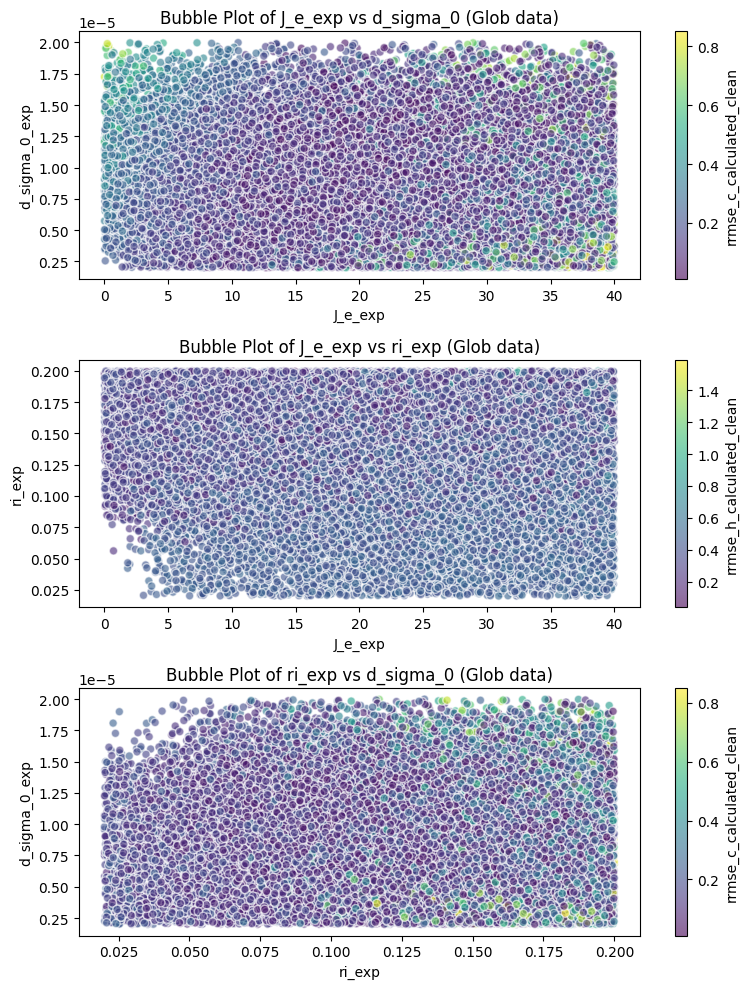

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

scatter_0 = ax[0].scatter(
    data_J_e_glob,
    data_d_sigma_0_glob,
    # s=sizes_filtered,
    c=rrmse_c_enhanced_pca_glob,
    # cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

fig.colorbar(scatter_0, ax=ax[0], label='rrmse_c_calculated_clean')
ax[0].set_xlabel('J_e_exp')
ax[0].set_ylabel('d_sigma_0_exp')
ax[0].set_title('Bubble Plot of J_e_exp vs d_sigma_0 (Glob data)')

scatter_1 = ax[1].scatter(
    data_J_e_glob,
    data_ri_glob,
    # s=sizes_filtered,
    c=rrmse_h_enhanced_pca_glob,
    # cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

fig.colorbar(scatter_1, ax=ax[1], label='rrmse_h_calculated_clean')
ax[1].set_xlabel('J_e_exp')
ax[1].set_ylabel('ri_exp')
ax[1].set_title('Bubble Plot of J_e_exp vs ri_exp (Glob data)')

scatter_2 = ax[2].scatter(
    data_ri_glob,
    data_d_sigma_0_glob,
    # s=sizes_filtered,
    c=rrmse_c_enhanced_pca_glob,
    # cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

fig.colorbar(scatter_2, ax=ax[2], label='rrmse_c_calculated_clean')
ax[2].set_xlabel('ri_exp')
ax[2].set_ylabel('d_sigma_0_exp')
ax[2].set_title('Bubble Plot of ri_exp vs d_sigma_0 (Glob data)')

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_glob.png", dpi=300)
plt.show()

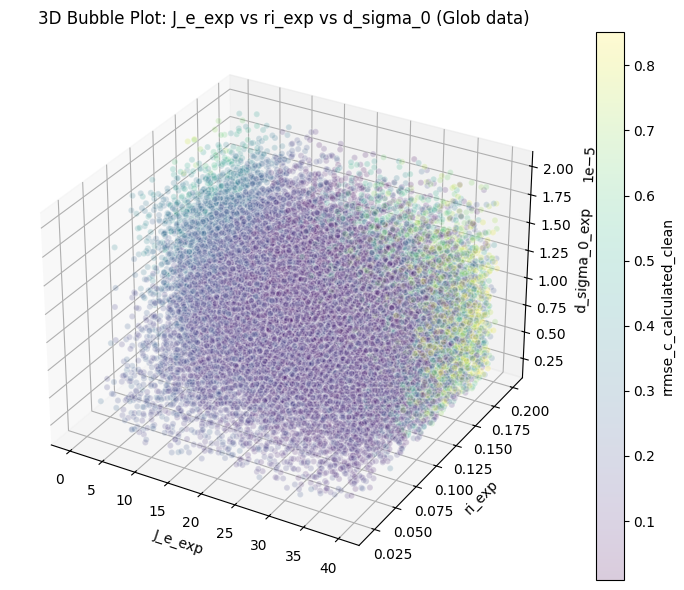

In [18]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter (bubble) plot
scatter = ax.scatter(
    data_J_e_glob,
    data_ri_glob,
    data_d_sigma_0_glob,
    c=rrmse_c_enhanced_pca_glob,  # color
    # s=sizes_filtered,            # optional bubble size
    alpha=0.2,
    edgecolors='w'
)

# colorbar and labels
fig.colorbar(scatter, ax=ax, label='rrmse_c_calculated_clean')
ax.set_xlabel('J_e_exp')
ax.set_ylabel('ri_exp')
ax.set_zlabel('d_sigma_0_exp')
ax.set_title('3D Bubble Plot: J_e_exp vs ri_exp vs d_sigma_0 (Glob data)')

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/3d_bubble_plot_glob.png", dpi=300)
plt.show()


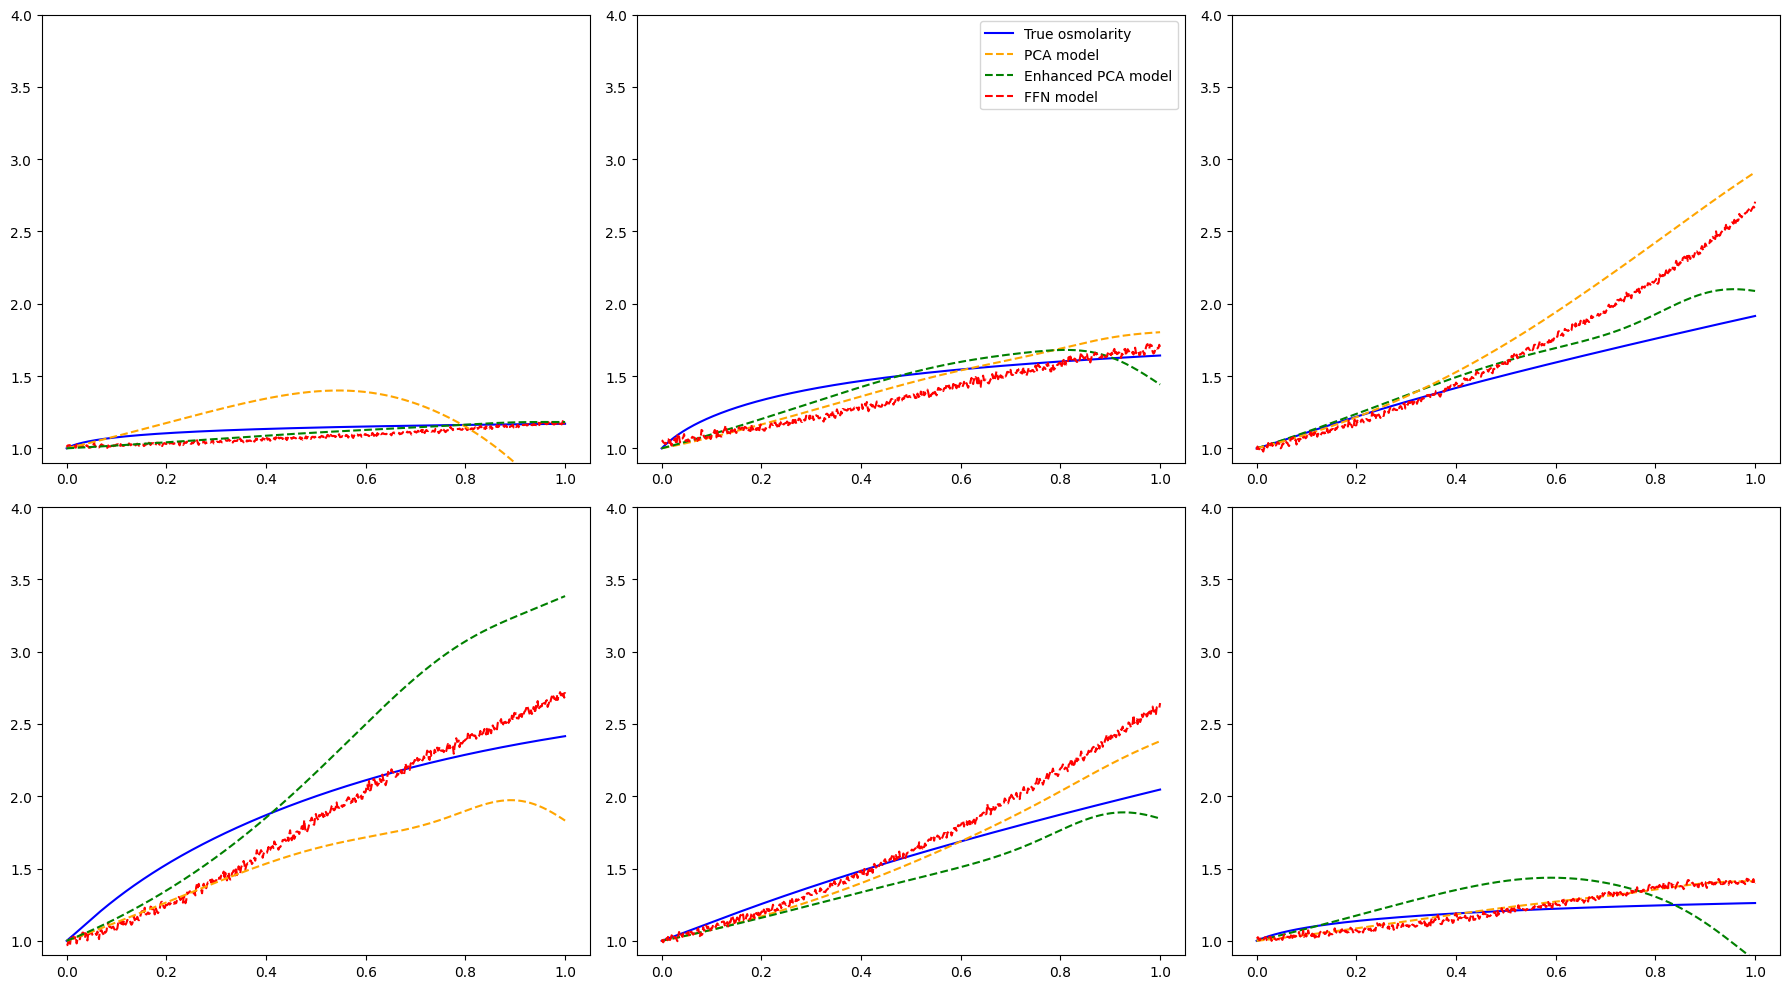

In [19]:
n1, n2, n3, n4, n5, n6 = np.random.randint(len(data_c_glob), size=6)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].plot(t, data_c_glob[n1], label='True osmolarity', color='blue')
ax[0, 0].plot(t, predictions_c_ffn_glob[n1], label='FFN model', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_c_enhanced_pca_glob[n1], label='PCA model', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_c_pca_glob[n1], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 0].set_ylim(0.9, 4)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_c_glob[n2], label='True osmolarity', color='blue')
ax[0, 1].plot(t, predictions_c_pca_glob[n2], label='PCA model', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_c_enhanced_pca_glob[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_c_ffn_glob[n2], label='FFN model', linestyle='--', color='red')
ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].legend()

ax[0, 2].plot(t, data_c_glob[n3], label='True osmolarity', color='blue')
ax[0, 2].plot(t, predictions_c_enhanced_pca_glob[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_c_pca_glob[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_c_ffn_glob[n3], label='FFN model', linestyle='--', color='red')
ax[0, 2].set_ylim(0.9, 4)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_c_glob[n4], label='True osmolarity', color='blue')
ax[1, 0].plot(t, predictions_c_ffn_glob[n4], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_c_enhanced_pca_glob[n4], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_c_pca_glob[n4], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 0].set_ylim(0.9, 4)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_c_glob[n5], label='True osmolarity', color='blue')
ax[1, 1].plot(t, predictions_c_pca_glob[n5], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_c_enhanced_pca_glob[n5], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_c_ffn_glob[n5], label='FFN model', linestyle='--', color='red')
ax[1, 1].set_ylim(0.9, 4)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_c_glob[n6], label='True osmolarity', color='blue')
ax[1, 2].plot(t, predictions_c_enhanced_pca_glob[n6], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_c_pca_glob[n6], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_c_ffn_glob[n6], label='FFN model', linestyle='--', color='red')
ax[1, 2].set_ylim(0.9, 4)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/6_samples_comparison_c_glob.png", dpi=300)
plt.show()


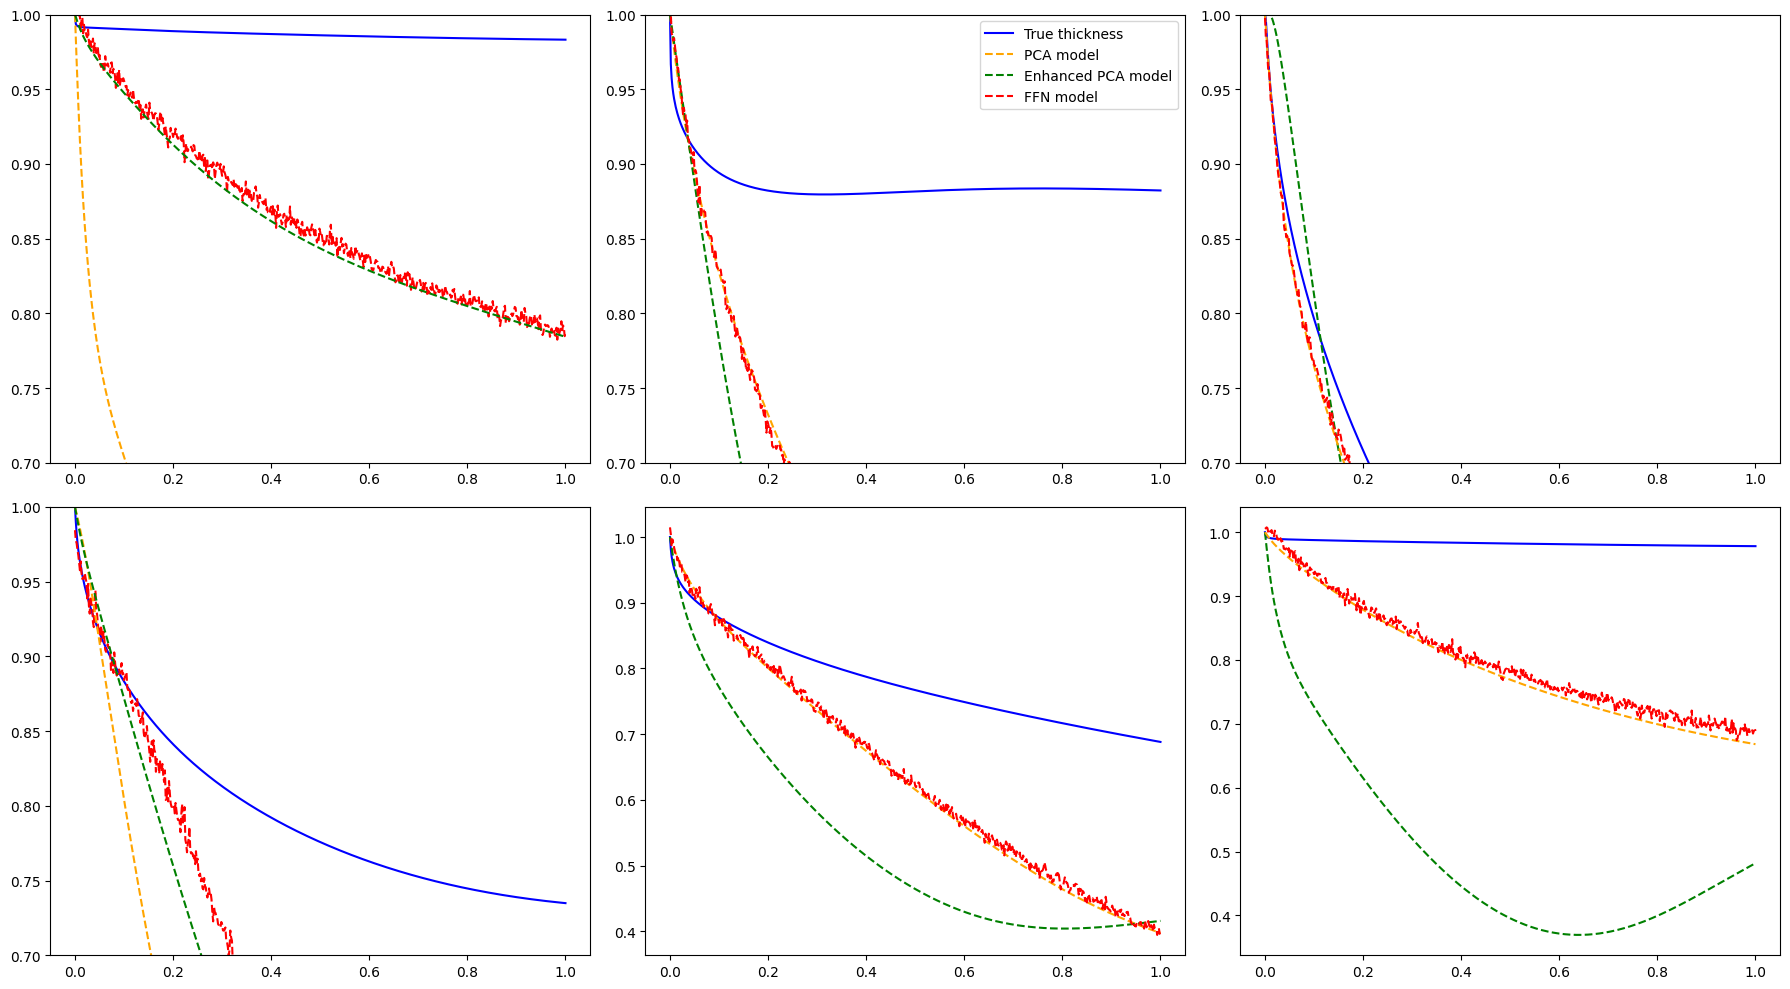

In [20]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].plot(t, data_h_glob[n1], label='True thickness', color='blue')
ax[0, 0].plot(t, predictions_h_ffn_glob[n1], label='FFN model', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_h_enhanced_pca_glob[n1], label='PCA model', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_h_pca_glob[n1], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 0].set_ylim(0.7, 1)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_h_glob[n2], label='True thickness', color='blue')
ax[0, 1].plot(t, predictions_h_pca_glob[n2], label='PCA model', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_h_enhanced_pca_glob[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_h_ffn_glob[n2], label='FFN model', linestyle='--', color='red')
ax[0, 1].set_ylim(0.7, 1)
ax[0, 1].legend()

ax[0, 2].plot(t, data_h_glob[n3], label='True thickness', color='blue')
ax[0, 2].plot(t, predictions_h_enhanced_pca_glob[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_h_pca_glob[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_h_ffn_glob[n3], label='FFN model', linestyle='--', color='red')
ax[0, 2].set_ylim(0.7, 1)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_h_glob[n4], label='True thickness', color='blue')
ax[1, 0].plot(t, predictions_h_ffn_glob[n4], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_h_enhanced_pca_glob[n4], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_h_pca_glob[n4], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 0].set_ylim(0.7, 1)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_h_glob[n5], label='True thickness', color='blue')
ax[1, 1].plot(t, predictions_h_pca_glob[n5], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_h_enhanced_pca_glob[n5], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_h_ffn_glob[n5], label='FFN model', linestyle='--', color='red')
ax[1, 0].set_ylim(0.7, 1)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_h_glob[n6], label='True thickness', color='blue')
ax[1, 2].plot(t, predictions_h_enhanced_pca_glob[n6], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_h_pca_glob[n6], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_h_ffn_glob[n6], label='FFN model', linestyle='--', color='red')
ax[1, 0].set_ylim(0.7, 1)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/6_samples_comparison_h_glob.png", dpi=300)
plt.show()

In [21]:
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
print("Keys in the HDF5 file:", list(datastore.keys()))
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f0_data_exp = data_p_experimental_nondimensional[:, 4] * 1e3
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_data_exp = data_p_experimental_nondimensional[:, 7] * 1e6
ts_data_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore.close()  # Close the read-only handle

Keys in the HDF5 file: ['calculated_I', 'calculated_c', 'calculated_f', 'calculated_h', 'nondimensional_p', 'predictions_c_ffn_calculated', 'predictions_h_ffn_calculated']


In [26]:
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"


datastore_exp = h5py.File(exprimental_data_path_h5, 'r')
id_array = datastore_exp['p']['id']

datastore_exp.close()

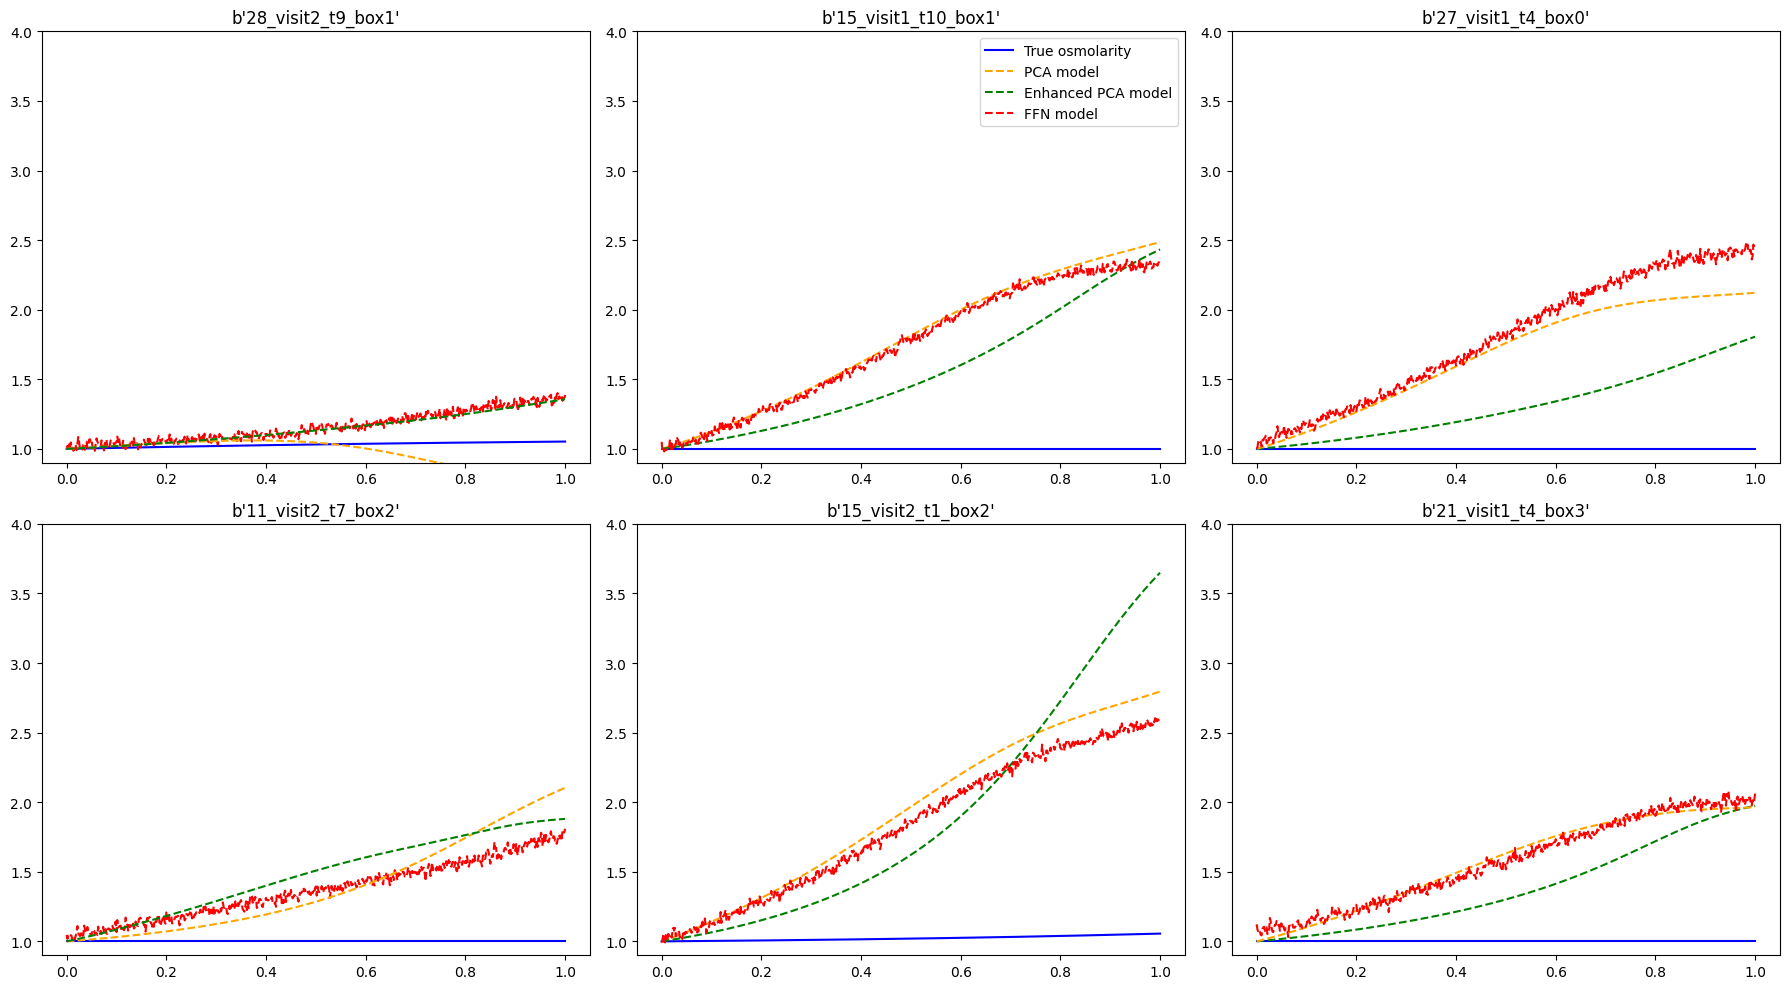

In [28]:
n1, n2, n3, n4, n5, n6 = np.random.randint(len(data_c_caluculated), size=6)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].plot(t, data_c_caluculated[n1], label='True osmolarity', color='blue')
ax[0, 0].plot(t, predictions_c_ffn_experimental[n1], label='FFN model', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_c_enhanced_pca_experimental[n1], label='PCA model', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_c_pca_experimental[n1], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 0].set_ylim(0.9, 4)
ax[0, 0].set_title(id_array[n1])
# ax[0, 0].legend()

ax[0, 1].plot(t, data_c_caluculated[n2], label='True osmolarity', color='blue')
ax[0, 1].plot(t, predictions_c_pca_experimental[n2], label='PCA model', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_c_enhanced_pca_experimental[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_c_ffn_experimental[n2], label='FFN model', linestyle='--', color='red')
ax[0, 1].set_ylim(0.9, 4)
ax[0, 1].set_title(id_array[n2])
ax[0, 1].legend()

ax[0, 2].plot(t, data_c_caluculated[n3], label='True osmolarity', color='blue')
ax[0, 2].plot(t, predictions_c_enhanced_pca_experimental[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_c_pca_experimental[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_c_ffn_experimental[n3], label='FFN model', linestyle='--', color='red')
ax[0, 2].set_ylim(0.9, 4)
ax[0, 2].set_title(id_array[n3])
# ax[0, 2].legend()

ax[1, 0].plot(t, data_c_caluculated[n4], label='True osmolarity', color='blue')
ax[1, 0].plot(t, predictions_c_ffn_experimental[n4], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_c_enhanced_pca_experimental[n4], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_c_pca_experimental[n4], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 0].set_ylim(0.9, 4)
ax[1, 0].set_title(id_array[n4])
# ax[1, 0].legend()

ax[1, 1].plot(t, data_c_caluculated[n5], label='True osmolarity', color='blue')
ax[1, 1].plot(t, predictions_c_pca_experimental[n5], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_c_enhanced_pca_experimental[n5], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_c_ffn_experimental[n5], label='FFN model', linestyle='--', color='red')
ax[1, 1].set_ylim(0.9, 4)
ax[1, 1].set_title(id_array[n5])
# ax[1, 1].legend()

ax[1, 2].plot(t, data_c_caluculated[n6], label='True osmolarity', color='blue')
ax[1, 2].plot(t, predictions_c_enhanced_pca_experimental[n6], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_c_pca_experimental[n6], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_c_ffn_experimental[n6], label='FFN model', linestyle='--', color='red')
ax[1, 2].set_ylim(0.9, 4)
ax[1, 2].set_title(id_array[n6])
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/6_samples_comparison_c_experimental.png", dpi=300)
plt.show()

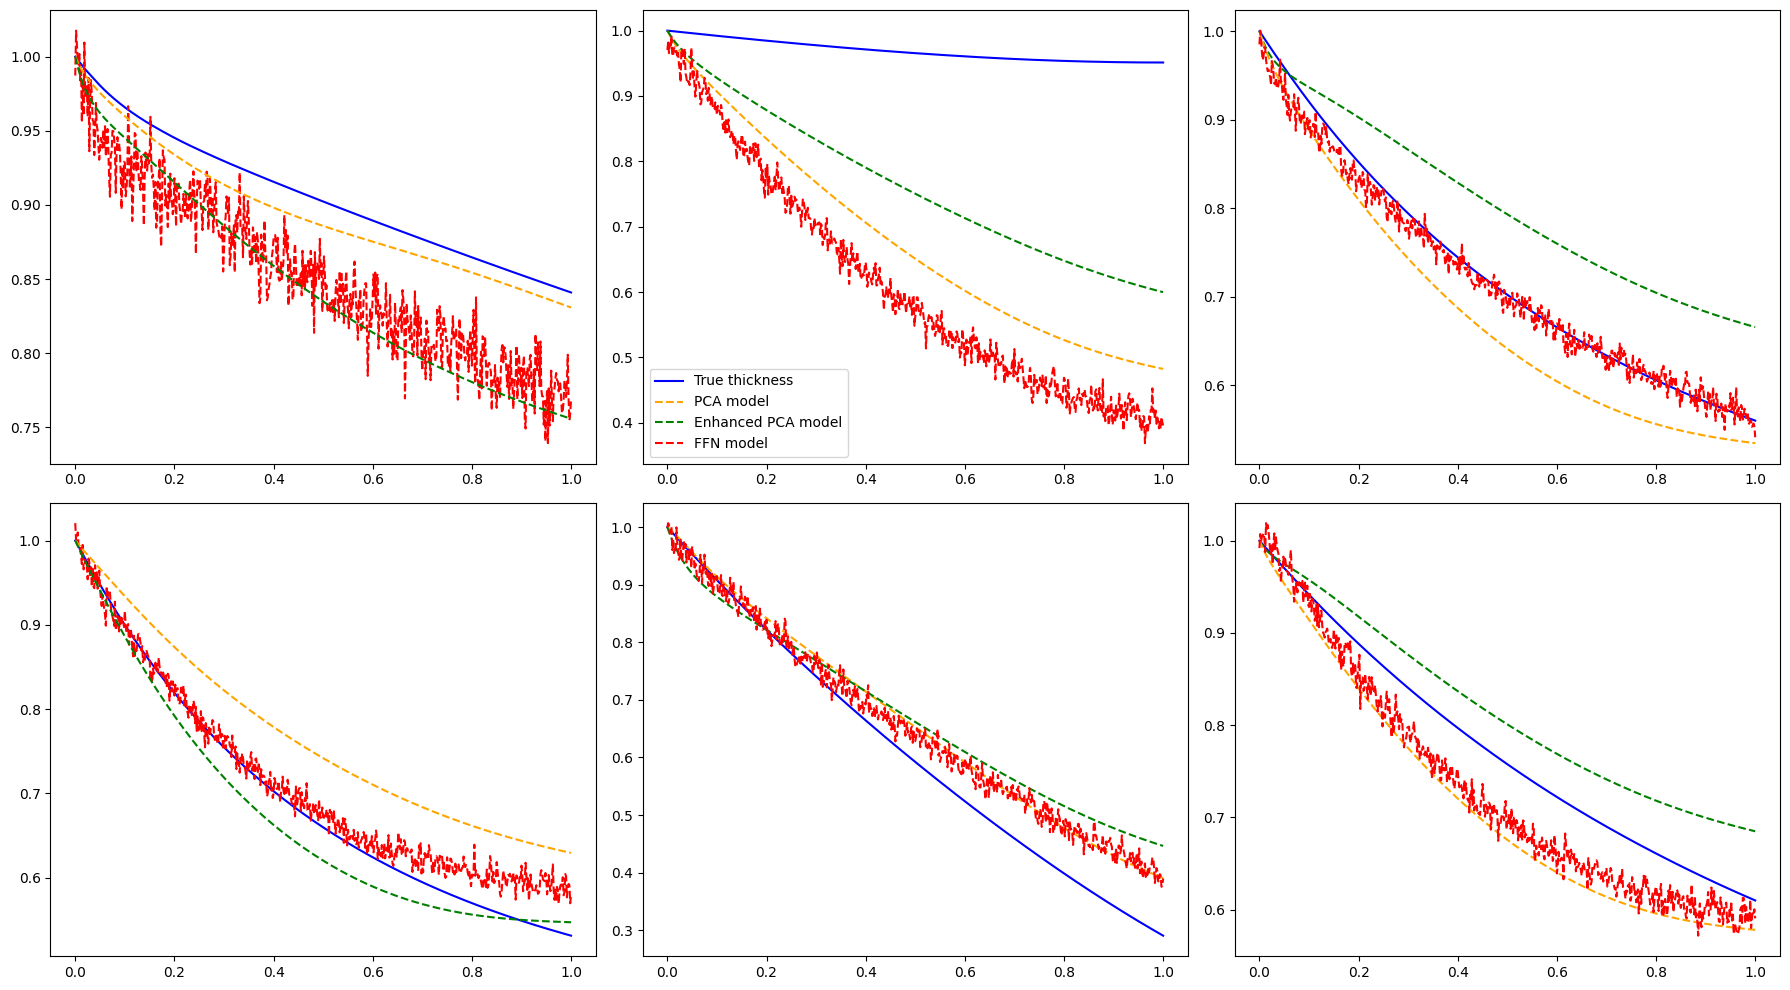

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0, 0].plot(t, data_h_calculated[n1], label='True thickness', color='blue')
ax[0, 0].plot(t, predictions_h_ffn_experimental[n1], label='FFN model', linestyle='--', color='red')
ax[0, 0].plot(t, predictions_h_enhanced_pca_experimental[n1], label='PCA model', linestyle='--', color='orange')
ax[0, 0].plot(t, predictions_h_pca_experimental[n1], label='Enhanced PCA model', linestyle='--', color='green')
# ax[0, 0].set_ylim(0.7, 1)
# ax[0, 0].legend()

ax[0, 1].plot(t, data_h_calculated[n2], label='True thickness', color='blue')
ax[0, 1].plot(t, predictions_h_pca_experimental[n2], label='PCA model', linestyle='--', color='orange')
ax[0, 1].plot(t, predictions_h_enhanced_pca_experimental[n2], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 1].plot(t, predictions_h_ffn_experimental[n2], label='FFN model', linestyle='--', color='red')
# ax[0, 1].set_ylim(0.7, 1)
ax[0, 1].legend()

ax[0, 2].plot(t, data_h_calculated[n3], label='True thickness', color='blue')
ax[0, 2].plot(t, predictions_h_enhanced_pca_experimental[n3], label='Enhanced PCA model', linestyle='--', color='green')
ax[0, 2].plot(t, predictions_h_pca_experimental[n3], label='PCA model', linestyle='--', color='orange')
ax[0, 2].plot(t, predictions_h_ffn_experimental[n3], label='FFN model', linestyle='--', color='red')
# ax[0, 2].set_ylim(0.7, 1)
# ax[0, 2].legend()

ax[1, 0].plot(t, data_h_calculated[n4], label='True thickness', color='blue')
ax[1, 0].plot(t, predictions_h_ffn_experimental[n4], label='FFN model', linestyle='--', color='red')
ax[1, 0].plot(t, predictions_h_enhanced_pca_experimental[n4], label='PCA model', linestyle='--', color='orange')
ax[1, 0].plot(t, predictions_h_pca_experimental[n4], label='Enhanced PCA model', linestyle='--', color='green')
# ax[1, 0].set_ylim(0.7, 1)
# ax[1, 0].legend()

ax[1, 1].plot(t, data_h_calculated[n5], label='True thickness', color='blue')
ax[1, 1].plot(t, predictions_h_pca_experimental[n5], label='PCA model', linestyle='--', color='orange')
ax[1, 1].plot(t, predictions_h_enhanced_pca_experimental[n5], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 1].plot(t, predictions_h_ffn_experimental[n5], label='FFN model', linestyle='--', color='red')
# ax[1, 1].set_ylim(0.7, 1)
# ax[1, 1].legend()

ax[1, 2].plot(t, data_h_calculated[n6], label='True thickness', color='blue')
ax[1, 2].plot(t, predictions_h_enhanced_pca_experimental[n6], label='Enhanced PCA model', linestyle='--', color='green')
ax[1, 2].plot(t, predictions_h_pca_experimental[n6], label='PCA model', linestyle='--', color='orange')
ax[1, 2].plot(t, predictions_h_ffn_experimental[n6], label='FFN model', linestyle='--', color='red')
# ax[1, 2].set_ylim(0.7, 1)
# ax[1, 2].legend()

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/6_samples_comparison_h_experimental.png", dpi=300)
plt.show()

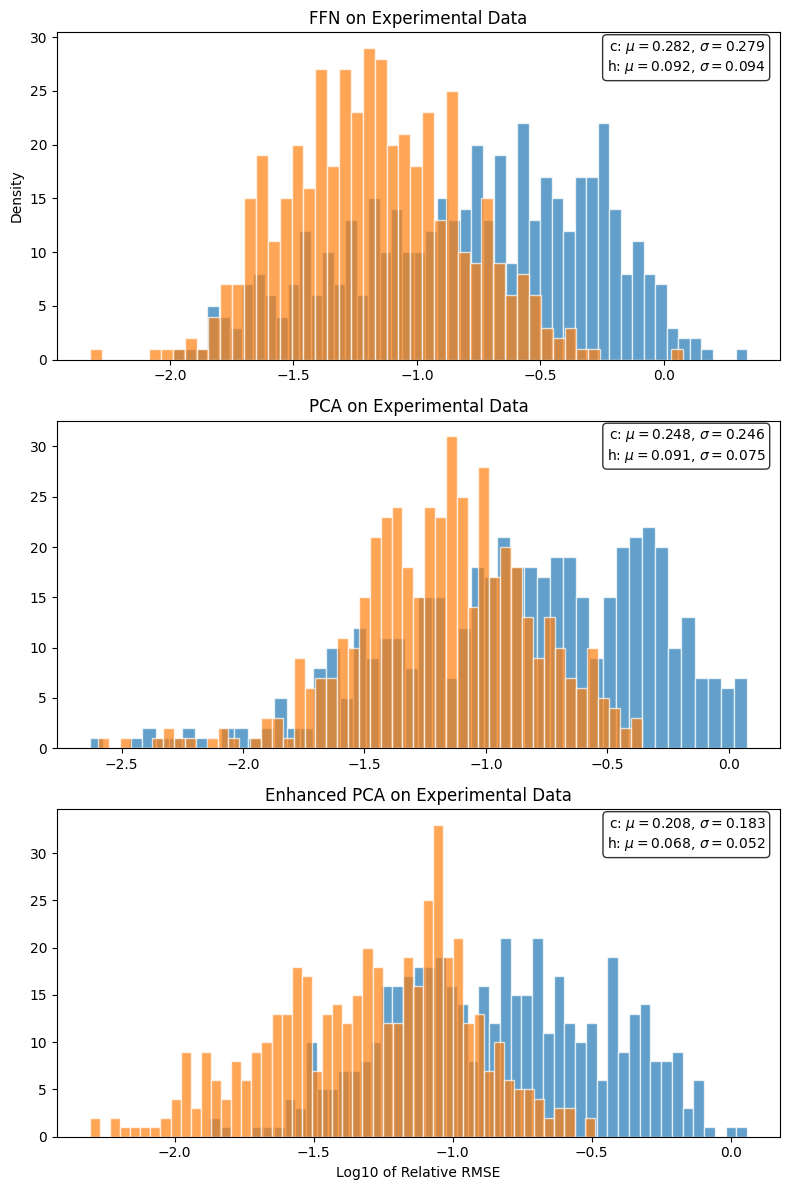

In [ ]:
rrmse_c_enhanced_pca_experimental = np.sqrt(np.sum((predictions_c_enhanced_pca_experimental - data_c_caluculated) ** 2, axis=1) / np.sum(data_c_caluculated ** 2, axis=1))
rrmse_h_enhanced_pca_experimental = np.sqrt(np.sum((predictions_h_enhanced_pca_experimental - data_h_calculated) ** 2, axis=1) / np.sum(data_h_calculated ** 2, axis=1))

rrmse_c_pca_experimental = np.sqrt(np.sum((predictions_c_pca_experimental - data_c_caluculated) ** 2, axis=1) / np.sum(data_c_caluculated ** 2, axis=1))
rrmse_h_pca_experimental = np.sqrt(np.sum((predictions_h_pca_experimental - data_h_calculated) ** 2, axis=1) / np.sum(data_h_calculated ** 2, axis=1))

rrmse_c_ffn_experimental = np.sqrt(np.sum((predictions_c_ffn_experimental - data_c_caluculated) ** 2, axis=1) / np.sum(data_c_caluculated ** 2, axis=1))
rrmse_h_ffn_experimental = np.sqrt(np.sum((predictions_h_ffn_experimental - data_h_calculated) ** 2, axis=1) / np.sum(data_h_calculated ** 2, axis=1))

fig, ax = plt.subplots(3, 1, figsize=(8, 12))

# FFN
mean_c_ffn_exp = np.mean(rrmse_c_ffn_experimental)
std_c_ffn_exp = np.std(rrmse_c_ffn_experimental)
mean_h_ffn_exp = np.mean(rrmse_h_ffn_experimental)
std_h_ffn_exp = np.std(rrmse_h_ffn_experimental)
ax[0].hist(np.log10(rrmse_c_ffn_experimental), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[0].hist(np.log10(rrmse_h_ffn_experimental), bins=50, alpha=0.7, label='h', edgecolor='white')
ax[0].set_ylabel('Density')
ax[0].set_title('FFN on Experimental Data')
textstr_ffn_exp = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_ffn_exp, std_c_ffn_exp),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_ffn_exp, std_h_ffn_exp)))
ax[0].text(0.98, 0.98, textstr_ffn_exp, transform=ax[0].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# PCA
mean_c_pca_exp = np.mean(rrmse_c_pca_experimental)
std_c_pca_exp = np.std(rrmse_c_pca_experimental)
mean_h_pca_exp = np.mean(rrmse_h_pca_experimental)
std_h_pca_exp = np.std(rrmse_h_pca_experimental)
ax[1].hist(np.log10(rrmse_c_pca_experimental), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[1].hist(np.log10(rrmse_h_pca_experimental), bins=50, alpha=0.7, label='h', edgecolor='white')
# ax[1].legend()
ax[1].set_title('PCA on Experimental Data')

textstr_pca_exp = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_pca_exp, std_c_pca_exp),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_pca_exp, std_h_pca_exp)))
ax[1].text(0.98, 0.98, textstr_pca_exp, transform=ax[1].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Enhanced PCA
mean_c_enh = np.mean(rrmse_c_enhanced_pca_experimental)
std_c_enh = np.std(rrmse_c_enhanced_pca_experimental)
mean_h_enh = np.mean(rrmse_h_enhanced_pca_experimental)
std_h_enh = np.std(rrmse_h_enhanced_pca_experimental)
ax[2].hist(np.log10(rrmse_c_enhanced_pca_experimental), bins=50, alpha=0.7, label='c', edgecolor='white')
ax[2].hist(np.log10(rrmse_h_enhanced_pca_experimental), bins=50, alpha=0.7, label='h', edgecolor='white')
ax[2].set_xlabel('Log10 of Relative RMSE')
ax[2].set_title('Enhanced PCA on Experimental Data')
textstr_enh = '\n'.join((
    r'c: $\mu=%.3f$, $\sigma=%.3f$' % (mean_c_enh, std_c_enh),
    r'h: $\mu=%.3f$, $\sigma=%.3f$' % (mean_h_enh, std_h_enh)))

ax[2].text(0.98, 0.98, textstr_enh, transform=ax[2].transAxes, fontsize=10,
           verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/rrmse_histograms_experimental.png", dpi=300)
plt.show()

In [ ]:
print(np.max(b_1_exp), np.max(b_2_exp))

22.685719219987565 96.0


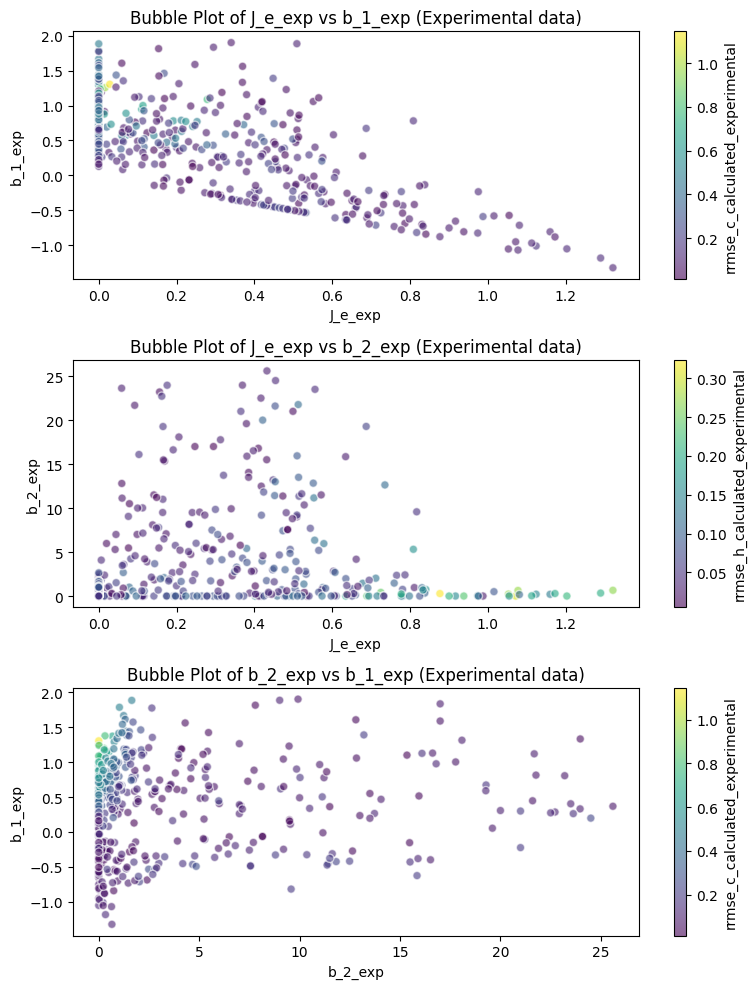

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# define threshold using 95th percentile
b1_threshold = np.percentile(b_1_exp, 95)
b2_threshold = np.percentile(b_2_exp, 95)

# keep only points below thresholds
mask = (b_1_exp < b1_threshold) & (b_2_exp < b2_threshold)

# filtered data
J_e_exp_f = J_e_exp[mask]
b_1_exp_f = b_1_exp[mask]
b_2_exp_f = b_2_exp[mask]
rrmse_c_f = rrmse_c_enhanced_pca_experimental[mask]
rrmse_h_f = rrmse_h_enhanced_pca_experimental[mask]

# same plotting code with filtered data
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

scatter_0 = ax[0].scatter(
    J_e_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_0, ax=ax[0], label='rrmse_c_calculated_experimental')
ax[0].set_xlabel('J_e_exp')
ax[0].set_ylabel('b_1_exp')
ax[0].set_title('Bubble Plot of J_e_exp vs b_1_exp (Experimental data)')

scatter_1 = ax[1].scatter(
    J_e_exp_f, b_2_exp_f,
    c=rrmse_h_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_1, ax=ax[1], label='rrmse_h_calculated_experimental')
ax[1].set_xlabel('J_e_exp')
ax[1].set_ylabel('b_2_exp')
ax[1].set_title('Bubble Plot of J_e_exp vs b_2_exp (Experimental data)')

scatter_2 = ax[2].scatter(
    b_2_exp_f, b_1_exp_f,
    c=rrmse_c_f, alpha=0.6, edgecolors='w'
)
fig.colorbar(scatter_2, ax=ax[2], label='rrmse_c_calculated_experimental')
ax[2].set_xlabel('b_2_exp')
ax[2].set_ylabel('b_1_exp')
ax[2].set_title('Bubble Plot of b_2_exp vs b_1_exp (Experimental data)')

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/bubble_plots_experimental_filtered.png", dpi=300)
plt.show()


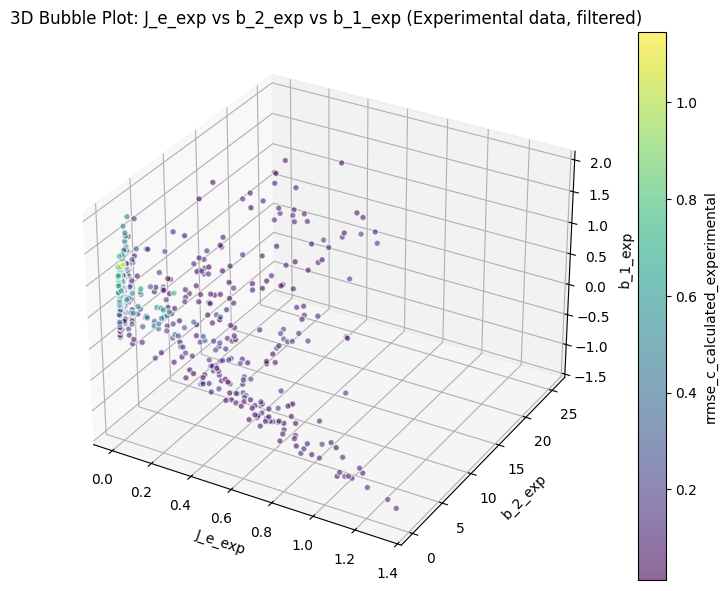

In [ ]:
# 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    J_e_exp_f,
    b_2_exp_f,
    b_1_exp_f,
    c=rrmse_c_f,
    # s=sizes_filtered[mask],  # uncomment if bubble sizes used
    alpha=0.6,
    edgecolors='w'
)

fig.colorbar(scatter, ax=ax, label='rrmse_c_calculated_experimental')
ax.set_xlabel('J_e_exp')
ax.set_ylabel('b_2_exp')
ax.set_zlabel('b_1_exp')
ax.set_title('3D Bubble Plot: J_e_exp vs b_2_exp vs b_1_exp (Experimental data, filtered)')

plt.tight_layout()
plt.savefig("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/final/3d_bubble_experimental_filtered.png", dpi=300)
plt.show()
